In [10]:
%pip install pytorch-lightning

In [11]:
%pip install pytorch-lightning torchmetrics

### Импорты

In [12]:
import os
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
from torchvision.datasets import MNIST
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint
import matplotlib.pyplot as plt
import seaborn as sns
from torchmetrics.classification import MulticlassConfusionMatrix
from PIL import Image, ImageDraw


### 1. ОПРЕДЕЛЕНИЕ МОДЕЛИ

In [13]:
class LitMNIST(pl.LightningModule):
    def __init__(self, hidden_dim=128, learning_rate=1e-3):
        super().__init__()
        self.save_hyperparameters() # Автоматически сохраняет аргументы в self.hparams
        
        # Простая полносвязная сеть
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 10)
        )
        
        self.test_cm = MulticlassConfusionMatrix(num_classes=10)

    def forward(self, x):
        return self.net(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        
        # Логирование метрик (отобразится в прогресс-баре)
        self.log("train_loss", loss, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        
        # Расчет Accuracy
        preds = torch.argmax(logits, dim=1)
        acc = (preds == y).float().mean()
        
        self.log_dict({"val_loss": loss, "val_acc": acc}, prog_bar=True)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.hparams.learning_rate)

### 2. ПОДГОТОВКА ДАННЫХ

In [14]:
class MNISTDataModule(pl.LightningDataModule):
    def __init__(self, data_dir="./data", batch_size=64):
        super().__init__()
        self.data_dir = data_dir
        self.batch_size = batch_size
        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.1307,), (0.3081,))
        ])

    def prepare_data(self):
        # Скачивание датасета (выполняется в 1 процессе)
        MNIST(self.data_dir, train=True, download=True)
        MNIST(self.data_dir, train=False, download=True)

    def setup(self, stage=None):
        # Разделение данных для каждого GPU/процесса
        if stage == "fit" or stage is None:
            mnist_full = MNIST(self.data_dir, train=True, transform=self.transform)
            self.mnist_train, self.mnist_val = random_split(mnist_full, [55000, 5000])

        if stage == "test" or stage is None:
            self.mnist_test = MNIST(self.data_dir, train=False, transform=self.transform)

    def train_dataloader(self):
        return DataLoader(self.mnist_train, batch_size=self.batch_size, shuffle=True, num_workers=2)

    def val_dataloader(self):
        return DataLoader(self.mnist_val, batch_size=self.batch_size, num_workers=2)

    def test_dataloader(self):
        return DataLoader(self.mnist_test, batch_size=self.batch_size, num_workers=2)


### 3. ЗАПУСК ОБУЧЕНИЯ

In [15]:

# Фиксация seed для воспроизводимости
pl.seed_everything(42)

# Инициализация модуля данных и модели
data_module = MNISTDataModule(batch_size=64)
model = LitMNIST(hidden_dim=128, learning_rate=1e-3)

# Настройка сохранения
checkpoint_callback = ModelCheckpoint(
    dirpath="./my_saved_models",       # Папка для сохранения
    filename="best-mnist-{epoch:02d}", # Имя файла (включает номер эпохи)
    monitor="val_acc",                 # На какую метрику смотреть
    mode="max",                        # Сохраняем модель с МАКСИМАЛЬНЫМ val_acc
    save_top_k=1,                      # Хранить только 1 лучшую модель
)

# Настройка тренера
trainer = pl.Trainer(
    max_epochs=2,                  # Количество эпох
    accelerator="auto",            # Авто-выбор (GPU, TPU или CPU)
    devices="auto",                # Использовать все доступные ресурсы
    callbacks=[checkpoint_callback] # Включаем сохранение
)

# Обучение
trainer.fit(model, datamodule=data_module)


INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type                      ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ net     │ Sequential                │  101 K │ train │     0 │
│ 1 │ test_cm │ MulticlassConfusionMatrix │      0 │ train │     0 │
└───┴─────────┴───────────────────────────┴────────┴───────┴───────┘

Trainable params: 101 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 101 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 6                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=2` reached.


### 4. ТЕСТИРОВАНИЕ И МАТРИЦА ОШИБОК

In [16]:
# Динамически добавляем метод test_step
def test_step(self, batch, batch_idx):
    x, y = batch
    logits = self(x)
    preds = torch.argmax(logits, dim=1)
    
    # Обновляем состояние матрицы ошибок (находится на том же девайсе, что и данные)
    self.test_cm.update(preds, y)
    
    acc = (preds == y).float().mean()
    self.log("test_acc", acc)
    return acc

LitMNIST.test_step = test_step

# Запуск тестирования
trainer.test(model, datamodule=data_module)

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.9677000045776367     │
└───────────────────────────┴───────────────────────────┘

[{'test_acc': 0.9677000045776367}]

### 5. Цикл сохранения ПОСЛЕ теста

In [17]:
print("🔄 Начинаем сохранение картинок с ошибками и подписями...")

mean, std = 0.1307, 0.3081
model.eval()

SAVE_DIR = "./error_images"
os.makedirs(SAVE_DIR, exist_ok=True)

with torch.no_grad():
    for batch_idx, batch in enumerate(data_module.test_dataloader()):
        x, y = batch
        x = x.to(model.device) # Переносим на GPU/CPU
        logits = model(x)
        preds = torch.argmax(logits, dim=1)
        
        incorrect_mask = (preds != y).cpu()
        
        if not incorrect_mask.any():
            continue
            
        err_images = x[incorrect_mask].cpu()
        err_preds = preds[incorrect_mask].cpu()
        err_targets = y[incorrect_mask].cpu()
        
        for i in range(len(err_images)):
            # Шаг А: Денормализация
            img_tensor = err_images[i].squeeze() * std + mean
            img_tensor = img_tensor.clamp(0, 1)
            
            p = err_preds[i].item()
            t = err_targets[i].item()
            
            # Шаг Б: Конвертация тензора в PIL Image
            img_np = (img_tensor.numpy() * 255).astype('uint8')
            pil_img = Image.fromarray(img_np).convert('RGB')
            
            # Шаг В: Рисуем текст (Истина и Предсказано)
            draw = ImageDraw.Draw(pil_img)
            # Текст: Зеленым (Истина), Красным (Прогноз)
            draw.text((1, 1), f"T:{t}", fill=(0, 255, 0))
            draw.text((1, 15), f"P:{p}", fill=(255, 0, 0))
            
            # Шаг Г: Сохранение по папкам
            sub_folder = os.path.join(SAVE_DIR, f"true_{t}_pred_{p}")
            os.makedirs(sub_folder, exist_ok=True)
            
            file_name = f"batch_{batch_idx}_img_{i}.png"
            pil_img.save(os.path.join(sub_folder, file_name))

print(f"✅ Готово! Все ошибочные изображения сохранены в папку: ./error_images")

🔄 Начинаем сохранение картинок с ошибками и подписями...
✅ Готово! Все ошибочные изображения сохранены в папку: ./error_images


### 6. Визуализация матрицы ошибок

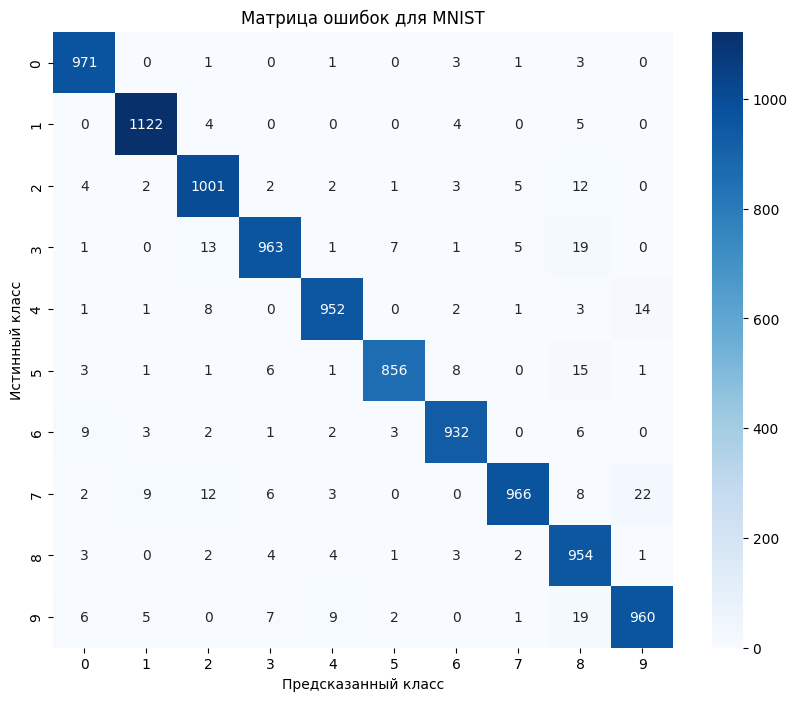

In [18]:
cm_tensor = model.test_cm.compute()

plt.figure(figsize=(10, 8))
sns.heatmap(cm_tensor.cpu().numpy().astype(int), annot=True, fmt='d', cmap='Blues',
            xticklabels=list(range(10)), yticklabels=list(range(10)))
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.title("Матрица ошибок для MNIST")
plt.show()